# Evaluación: Lector de Dígitos OCR (Pretrained)

Notebook para la evaluación iterativa del Lector de Dígitos (PaddleOCR) sobre crops de odómetros de medidores de agua. Evalúa modelos pretrained sin fine-tuning.

## Dataset

- **Fuente**: `data/ocr/` (construido por `scripts/build/build_ocr.py`)
- **Crops**: 1,199 (rotados + masked, labels enteros solamente)
- **Split estratificado**: 959 train / 120 val / 120 test (80/10/10)
- **Estratificación**: por background (bgwhite/bgblack), n_digits, has_decimal
- **Formato labels**: PaddleOCR (`images/{split}/{name}\t{integer_label}`)

## Diseño de Experimentos

Se sigue un diseño iterativo de **una variable a la vez** con selección greedy sobre val.

**Sanitización**: siempre aplicada (filtro digit-only, costo cero).

**Métrica principal**: Exact Match Accuracy. Val para decisiones, test solo al final.

### Fase 1 — Preprocessing (modelo mobile fijo)

Evalúa el impacto del algoritmo de masking de dígitos rojos. Modelo fijo: PP-OCRv5 mobile.

| # | Nombre | Cambio | Objetivo |
|---|---|---|---|
| P0 | Sin máscara | Raw crops (sin masking) | Baseline — ¿el masking aporta? |
| P1 | Máscara HSV | Detección HSV absoluta + TELEA inpainting (masking v1) | Primer approach de masking |
| P2 | Máscara LAB | Detección LAB relativa + TELEA + supresión a* (masking v4) | Approach final optimizado |

### Fase 2 — Modelo (datos con mejor preprocessing)

Parte del mejor preprocessing de Fase 1.

| Iteración | Cambio | Valor | Objetivo |
|---|---|---|---|
| **Baseline** | — | PP-OCRv5 mobile (det + rec) | Punto de referencia |
| Iter 1 | Pipeline | det+rec → rec-only | Eliminar ruido del detector |
| Iter 2 | Escala | mobile → server (rec-only) | Mayor capacidad |
| Iter 3 | Versión | PP-OCRv5 → PP-OCRv4 english | Vocabulario reducido (solo ASCII) |
| Iter 4 | Fine-tuning | en_PP-OCRv4_mobile_rec | Adaptación al dominio |

---

## PARTE 1: CONFIGURACIÓN DEL ENTORNO

### 1.1 Verificar GPU disponible

GPU es útil para acelerar la inferencia OCR pero no es estrictamente necesaria. CPU es suficiente para evaluar ~120 imágenes.

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("GPU no disponible. OCR inference puede ejecutarse en CPU.")

PyTorch version: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
CUDA version: 12.8
Memoria GPU: 15.64 GB


### 1.2 Instalar dependencias

In [ ]:
import os, subprocess
os.environ['PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK'] = 'True'

# Detect CUDA version for correct paddlepaddle-gpu index
cuda_version = subprocess.check_output(
    "nvcc --version | grep -oP 'release \\K[0-9]+'", shell=True
).decode().strip()
cuda_tag = {'11': 'cu118', '12': 'cu126'}.get(cuda_version, 'cu126')
print(f"CUDA major version: {cuda_version} -> using {cuda_tag} index")

# --no-deps avoids re-downloading ~1.2 GB of NVIDIA CUDA libs that Colab
# already ships.  --trusted-host bypasses the expired SSL certificate on the
# PaddlePaddle mirror (v3.2.0 is not on PyPI, only on their own index).
get_ipython().system(
    f'pip install -q paddlepaddle-gpu==3.2.0 --no-deps'
    f' --trusted-host www.paddlepaddle.org.cn'
    f' -i https://www.paddlepaddle.org.cn/packages/stable/{cuda_tag}/'
)
get_ipython().system('pip install -q paddleocr editdistance')
get_ipython().system('pip uninstall -y langchain langchain-community 2>/dev/null')

import paddle, paddleocr
print(f"PaddlePaddle version: {paddle.__version__}")
print(f"CUDA available: {paddle.device.is_compiled_with_cuda()}")
print(f"PaddleOCR version: {paddleocr.__version__}")

### 1.3 Montar Google Drive

**IMPORTANTE:** Antes de ejecutar esta celda, sube `data/ocr/` y `data/annotations/` a tu Google Drive.

La estructura esperada en Drive es:
```
MyDrive/water-meter-training/
├── data/
│   ├── ocr/                           # Construido por scripts/build/build_ocr.py
│   │   ├── images/{train,val,test}/
│   │   └── {train,val,test}.txt
│   └── annotations/                   # Para metadata y comparación raw vs masked
│       ├── metadata.csv
│       ├── ocr-labels.csv
│       └── ocr-crops/
│
└── ocr-reader/                        # Generado por este notebook
    ├── dataset/                         # Copia local del dataset
    └── export/                            # Resultados por iteración
        ├── baseline/
        │   ├── results.csv
        │   ├── summary.md
        │   └── eval_config.yaml
        ├── iter1-sanitization/
        └── iter2-architecture/
```

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

DRIVE_MOUNT_PATH = '/content/drive/MyDrive/water-meter-training'

if os.path.exists(f'{DRIVE_MOUNT_PATH}/data/ocr'):
    print(f"Dataset OCR encontrado en: {DRIVE_MOUNT_PATH}/data/ocr")
else:
    print(f"ADVERTENCIA: No se encontro data/ocr/ en {DRIVE_MOUNT_PATH}")
    print("Sube data/ocr/ a Drive antes de continuar")

if os.path.exists(f'{DRIVE_MOUNT_PATH}/data/annotations'):
    print(f"Annotations encontrado en: {DRIVE_MOUNT_PATH}/data/annotations")
else:
    print(f"ADVERTENCIA: No se encontro data/annotations/ en {DRIVE_MOUNT_PATH}")
    print("Necesario para metadata y comparacion raw vs masked (Apendice A)")

Mounted at /content/drive
Dataset OCR encontrado en: /content/drive/MyDrive/water-meter-training/data/ocr
Annotations encontrado en: /content/drive/MyDrive/water-meter-training/data/annotations


### 1.4 Configuración de Rutas del Proyecto

In [4]:
# =====================================================
# CONFIGURACION DE RUTAS
# =====================================================

DRIVE_BASE = '/content/drive/MyDrive/water-meter-training'

# Dataset fuente (construido por scripts/build/build_ocr.py)
SOURCE_OCR_PATH = f'{DRIVE_BASE}/data/ocr'

# Annotations (metadata + raw crops para comparacion)
SOURCE_ANNOTATIONS = f'{DRIVE_BASE}/data/annotations'

# Componente: ocr-reader
COMPONENT_DIR = f'{DRIVE_BASE}/ocr-reader'
EXPORT_DIR = f'{COMPONENT_DIR}/export'

# Workspace local (dataset copiado)
DATASET_PATH = f'{COMPONENT_DIR}/dataset'

# =====================================================
# Rutas derivadas (no modificar)
# =====================================================
LABEL_FILES = {s: f'{DATASET_PATH}/{s}.txt' for s in ['train', 'val', 'test']}
SPLIT_IMAGE_DIRS = {s: f'{DATASET_PATH}/images/{s}' for s in ['train', 'val', 'test']}
METADATA_CSV = f'{SOURCE_ANNOTATIONS}/metadata.csv'
OCR_LABELS_CSV = f'{SOURCE_ANNOTATIONS}/ocr-labels.csv'
RAW_CROPS_DIR = f'{SOURCE_ANNOTATIONS}/ocr-crops'

# Crear directorios
os.makedirs(COMPONENT_DIR, exist_ok=True)

print("=== CONFIGURACION DE RUTAS ===")
print(f"Dataset fuente:    {SOURCE_OCR_PATH}")
print(f"Annotations:       {SOURCE_ANNOTATIONS}")
print(f"Componente:        {COMPONENT_DIR}")
print(f"  dataset/         {DATASET_PATH}")
print(f"  export/            {EXPORT_DIR}")

=== CONFIGURACION DE RUTAS ===
Dataset fuente:    /content/drive/MyDrive/water-meter-training/data/ocr
Annotations:       /content/drive/MyDrive/water-meter-training/data/annotations
Componente:        /content/drive/MyDrive/water-meter-training/ocr-reader
  dataset/         /content/drive/MyDrive/water-meter-training/ocr-reader/dataset
  export/            /content/drive/MyDrive/water-meter-training/ocr-reader/export


### 1.5 Importar bibliotecas necesarias

In [5]:
import os
import re
import csv
import time
import shutil
import random
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import yaml
import editdistance
from paddleocr import PaddleOCR

# Fijar semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

IMG_EXTS = ('.jpg', '.jpeg', '.png')

def count_images(directory):
    """Cuenta imagenes en un directorio."""
    return len([f for f in os.listdir(directory) if f.lower().endswith(IMG_EXTS)])

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


---

## PARTE 2: PREPARACIÓN DEL DATASET

### 2.1 Copiar Dataset a Workspace

Copia `data/ocr/` desde Drive al workspace del componente. El dataset ya incluye el split estratificado y los labels en formato PaddleOCR.

In [6]:
# Copiar dataset fresco a workspace (siempre limpia y re-copia)
# Esto garantiza que cada iteracion use el data/ocr/ correcto,
# evitando arrastrar datos de una iteracion anterior (P0/P1/P2).
FORCE_DATASET_COPY = True  # Default True — cambiar a False solo para debug rapido

if FORCE_DATASET_COPY or not os.path.exists(DATASET_PATH) or not os.path.exists(LABEL_FILES['val']):
    if not os.path.exists(SOURCE_OCR_PATH):
        raise FileNotFoundError(f"Dataset fuente no encontrado: {SOURCE_OCR_PATH}")

    if os.path.exists(DATASET_PATH):
        shutil.rmtree(DATASET_PATH)
        print(f"Limpiado: {DATASET_PATH}")

    print(f"Copiando {SOURCE_OCR_PATH} -> {DATASET_PATH} ...")
    shutil.copytree(SOURCE_OCR_PATH, DATASET_PATH)
    print("Copia completada")
else:
    print("Dataset ya existe en workspace, omitiendo copia (FORCE_DATASET_COPY=False)")

# Verificar estructura
SPLITS = ['train', 'val', 'test']
print("\n=== DATASET EN WORKSPACE ===")
total = 0
for split in SPLITS:
    img_dir = SPLIT_IMAGE_DIRS[split]
    n_imgs = count_images(img_dir)
    label_file = LABEL_FILES[split]
    with open(label_file, 'r') as f:
        n_labels = sum(1 for line in f if line.strip())
    print(f"  {split:5s}: {n_imgs} images, {n_labels} labels")
    assert n_imgs == n_labels, f"Mismatch en {split}: {n_imgs} imgs vs {n_labels} labels"
    total += n_imgs

print(f"  Total: {total}")

Limpiado: /content/drive/MyDrive/water-meter-training/ocr-reader/dataset
Copiando /content/drive/MyDrive/water-meter-training/data/ocr -> /content/drive/MyDrive/water-meter-training/ocr-reader/dataset ...
Copia completada

=== DATASET EN WORKSPACE ===
  train: 959 images, 959 labels
  val  : 120 images, 120 labels
  test : 120 images, 120 labels
  Total: 1199


### 2.2 Cargar Labels y Metadata

Carga los labels de los archivos `.txt` y los une con `metadata.csv` para obtener el flag `has_decimal` por imagen. Esto permite el desglose de métricas por tipo de medidor.

In [7]:
def load_split_labels(split_file):
    """Carga archivo de labels PaddleOCR -> DataFrame."""
    entries = []
    with open(split_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            img_path = parts[0]  # e.g. "images/val/00002.jpg"
            label = parts[1]
            filename = os.path.basename(img_path)
            entries.append({'filename': filename, 'label': label, 'rel_path': img_path})
    return pd.DataFrame(entries)


def load_metadata(metadata_path):
    """Carga metadata.csv -> DataFrame con info de has_decimal por imagen."""
    df = pd.read_csv(metadata_path)
    df['has_decimal'] = df['has_decimal'].apply(lambda x: str(x).strip() == 'True')
    return df[['image', 'has_decimal', 'background', 'n_digits', 'group', 'split']]


# Cargar labels de val y test
val_df = load_split_labels(LABEL_FILES['val'])
test_df = load_split_labels(LABEL_FILES['test'])

# Cargar metadata y hacer join
meta_df = load_metadata(METADATA_CSV)
meta_df = meta_df.rename(columns={'image': 'filename'})

val_df = val_df.merge(meta_df[['filename', 'has_decimal', 'background', 'n_digits']], on='filename', how='left')
test_df = test_df.merge(meta_df[['filename', 'has_decimal', 'background', 'n_digits']], on='filename', how='left')

print(f"Val set:  {len(val_df)} imagenes "
      f"({val_df['has_decimal'].sum()} con_decimal, "
      f"{(~val_df['has_decimal']).sum()} sin_decimal)")
print(f"Test set: {len(test_df)} imagenes "
      f"({test_df['has_decimal'].sum()} con_decimal, "
      f"{(~test_df['has_decimal']).sum()} sin_decimal)")

Val set:  120 imagenes (84 con_decimal, 36 sin_decimal)
Test set: 120 imagenes (84 con_decimal, 36 sin_decimal)


### 2.3 Visualizar Muestras del Dataset

Crops procesados (rotados + HSV masked) tal como los verá el modelo OCR.

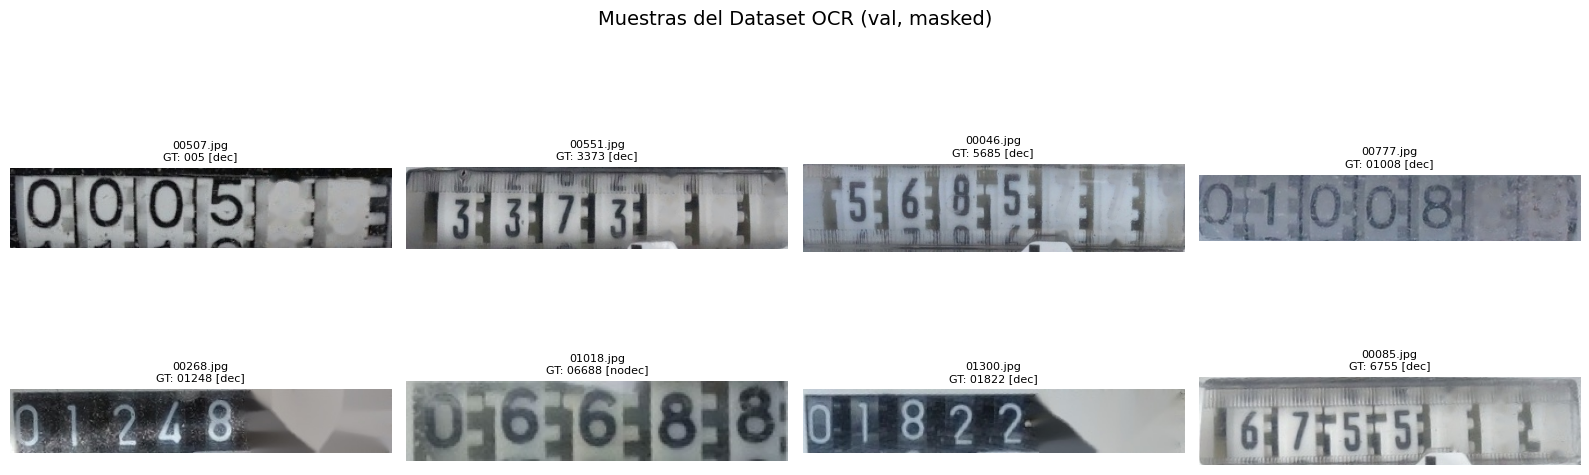

In [8]:
# Mostrar 8 crops aleatorios del val set
sample_val = val_df.sample(n=min(8, len(val_df)), random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.ravel()

for idx, (_, row) in enumerate(sample_val.iterrows()):
    img_path = f"{DATASET_PATH}/{row['rel_path']}"
    img = Image.open(img_path)

    dec_str = 'dec' if row['has_decimal'] else 'nodec'
    title = f"{row['filename']}\nGT: {row['label']} [{dec_str}]"

    axes[idx].imshow(img)
    axes[idx].set_title(title, fontsize=8)
    axes[idx].axis('off')

for idx in range(len(sample_val), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Muestras del Dataset OCR (val, masked)', fontsize=14)
plt.tight_layout()
plt.show()

---

## PARTE 3: CONFIGURACIÓN DEL MODELO

### 3.1 Selección del Modelo y Configuración de Iteración

| Iteración | `RUN_NAME` | Detector | Reconocedor | `EVAL_SPLIT` |
|---|---|---|---|---|
| **Baseline** | `f2/baseline` | `PP-OCRv5_mobile_det` | `en_PP-OCRv5_mobile_rec` | val |
| **Iter 1** | `f2/iter1-det-bypass` | — (rec-only) | `en_PP-OCRv5_mobile_rec` | val |
| **Iter 2** | `f2/iter2-scaling` | — (rec-only) | `PP-OCRv5_server_rec` | val |
| **Iter 3** | `f2/iter3-v4-english` | — (rec-only) | `en_PP-OCRv4_mobile_rec` | val |
| **Iter 4** | `f2/iter4-finetune` | — (rec-only) | fine-tuned rec | val |
| **Final** | (ganador) | (ganador) | (ganador) | **test** |

**Nota:** `OCR_DET_MODEL_NAME` y `OCR_MODEL_NAME` siempre explícitos.


In [9]:
# =====================================================
# CONFIGURACION DE ITERACION — Modificar para cada run
# =====================================================

# --- Fase 1: Preprocessing (P0, P1, P2) ---
# f1/p0-raw          — Raw crops, sin masking
# f1/p1-mask-hsv     — Masking v1: HSV absoluto + TELEA
# f1/p2-mask-lab     — Masking v4: LAB relativo + TELEA + supresión a*
#
# --- Fase 2: Modelo (baseline, iter1..iter4) ---
# f2/baseline:          PP-OCRv5 mobile (det+rec) — misma config que P2, establece referencia
# f2/iter1-det-bypass:  Rec-only mobile v5 (omitir detector)         ← EM 0.1583
# f2/iter2-scaling:     Rec-only server v5 (multilingue)             ← EM 0.1333 (revertido)
# f2/iter3-v4-english:  Rec-only mobile v4 (english-only)           ← ACTUAL
# f2/iter4-finetune:    Fine-tune rec

RUN_NAME = 'f2/iter3-v4-english'
RUN_DESCRIPTION = 'Fase 2 — Iter 3: Rec-only PP-OCRv4 mobile english, datos P2 (LAB mask), con sanitizacion'

# Modelo OCR — siempre explicito
# USE_DET controla si se usa det+rec (PaddleOCR) o rec-only (paddlex create_model)
USE_DET = False  # True = det+rec (PaddleOCR), False = rec-only (paddlex)

OCR_DET_MODEL_NAME = None  # None cuando USE_DET=False
OCR_MODEL_NAME = 'en_PP-OCRv4_mobile_rec'
OCR_VERSION = 'PP-OCRv4'  # Para display

# Post-procesamiento
USE_SANITIZATION = True   # Siempre True (incluido en baseline)

# Split para evaluacion iterativa
# 'val' durante iteraciones, 'test' SOLO al final con la configuracion ganadora
EVAL_SPLIT = 'val'

print('=== CONFIGURACION ===')
print(f'  Run:           {RUN_NAME}')
print(f'  Descripcion:   {RUN_DESCRIPTION}')
print(f'  Modo:          {"det+rec (PaddleOCR)" if USE_DET else "rec-only (paddlex)"}')
if USE_DET:
    print(f'  OCR detector:  {OCR_DET_MODEL_NAME}')
print(f'  OCR reconoc.:  {OCR_MODEL_NAME}')
print(f'  OCR version:   {OCR_VERSION}')
print(f'  Sanitization:  {USE_SANITIZATION}')
print(f'  Eval split:    {EVAL_SPLIT}')


=== CONFIGURACION ===
  Run:           f2/iter3-v4-english
  Descripcion:   Fase 2 — Iter 3: Rec-only PP-OCRv4 mobile english, datos P2 (LAB mask), con sanitizacion
  Modo:          rec-only (paddlex)
  OCR reconoc.:  en_PP-OCRv4_mobile_rec
  OCR version:   PP-OCRv4
  Sanitization:  True
  Eval split:    val


### 3.2 Filtro de Sanitización (Digit-Only)

Elimina caracteres no numéricos del output OCR. No aplica filtro de longitud para evitar descartar información válida.

In [10]:
DIGITS_ONLY_RE = re.compile(r'[^0-9]')


def sanitize_ocr_output(text):
    """Strip non-digit characters from OCR output.

    Returns cleaned digits string, or None if no digits found.
    """
    digits_only = DIGITS_ONLY_RE.sub('', text)
    return digits_only if digits_only else None


# Ejemplos
examples = [
    ('O9O66', '9066'),
    ('09.066', '09066'),
    ('09B66', '0966'),
    ('12', '12'),              # solo 2 digitos pero se conserva
    ('123456789', '123456789'),  # 9 digitos, se conserva
    ('abc', None),              # sin digitos
]
print('Ejemplos de sanitizacion (digit-only, sin filtro de longitud):')
for input_text, expected in examples:
    result = sanitize_ocr_output(input_text)
    status = 'OK' if result == expected else f'FAIL (esperado {expected})'
    print(f"  '{input_text}' -> {result!r}  {status}")

Ejemplos de sanitizacion (digit-only, sin filtro de longitud):
  'O9O66' -> '966'  FAIL (esperado 9066)
  '09.066' -> '09066'  OK
  '09B66' -> '0966'  OK
  '12' -> '12'  OK
  '123456789' -> '123456789'  OK
  'abc' -> None  OK


### 3.3 Funciones de Métricas

Métricas alineadas con el diseño de experimentos:
- **Exact Match Accuracy** (principal): % de crops donde la lectura entera completa es correcta
- **CER** (complementaria): Character Error Rate via distancia de edición
- **CRR** = 1 − CER: Character Recognition Rate (presentación positiva)

Se reportan en **tres niveles**: global, con_decimales, sin_decimales.

In [11]:
def compute_exact_match(predictions, ground_truths):
    """Exact Match Accuracy: % of predictions that exactly equal ground truth.

    None predictions count as incorrect.
    """
    correct = sum(1 for p, g in zip(predictions, ground_truths) if p == g)
    return correct / len(ground_truths) if ground_truths else 0.0


def compute_cer(predictions, ground_truths):
    """Character Error Rate: average normalized edit distance.

    None predictions are treated as empty string (maximum error).
    """
    total_distance = 0
    total_chars = 0
    for pred, gt in zip(predictions, ground_truths):
        pred_str = pred if pred is not None else ''
        total_distance += editdistance.eval(pred_str, gt)
        total_chars += len(gt)
    return total_distance / total_chars if total_chars > 0 else 0.0


def compute_metrics(predictions, ground_truths):
    """Compute all OCR metrics."""
    em = compute_exact_match(predictions, ground_truths)
    cer = compute_cer(predictions, ground_truths)
    return {
        'exact_match': em,
        'cer': cer,
        'crr': 1.0 - cer,
        'total': len(ground_truths),
        'correct': sum(1 for p, g in zip(predictions, ground_truths) if p == g),
    }


def compute_metrics_by_group(df):
    """Compute metrics globally and by has_decimal group."""
    results = {}

    # Global
    results['global'] = compute_metrics(
        df['prediction'].tolist(), df['label'].tolist())

    # Con decimales
    dec_df = df[df['has_decimal'] == True]
    if len(dec_df) > 0:
        results['with_decimal'] = compute_metrics(
            dec_df['prediction'].tolist(), dec_df['label'].tolist())

    # Sin decimales
    nodec_df = df[df['has_decimal'] == False]
    if len(nodec_df) > 0:
        results['without_decimal'] = compute_metrics(
            nodec_df['prediction'].tolist(), nodec_df['label'].tolist())

    return results


# Self-test
test_preds = ['12345', '12345', None, '1234']
test_gts =   ['12345', '12346', '5678', '12345']
test_result = compute_metrics(test_preds, test_gts)
assert test_result['correct'] == 1, f"Self-test failed: expected 1 correct, got {test_result['correct']}"
assert test_result['exact_match'] == 0.25, f"Self-test failed: expected EM=0.25, got {test_result['exact_match']}"
print(f"Self-test OK: EM={test_result['exact_match']:.2f}, "
      f"CER={test_result['cer']:.4f}, CRR={test_result['crr']:.4f}")

Self-test OK: EM=0.25, CER=0.3158, CRR=0.6842


---

## PARTE 4: EVALUACIÓN (INFERENCIA)

### 4.1 Inicializar Motor OCR

In [12]:
if USE_DET:
    print(f'Inicializando PaddleOCR ({OCR_VERSION}) — det+rec...')
    ocr_engine = PaddleOCR(
        use_textline_orientation=True,
        lang='en',
        enable_mkldnn=False,
        text_detection_model_name=OCR_DET_MODEL_NAME,
        text_recognition_model_name=OCR_MODEL_NAME,
    )
    print(f'Motor OCR inicializado: {OCR_VERSION} (det+rec)')
    print(f'  Detector:    {OCR_DET_MODEL_NAME}')
    print(f'  Reconocedor: {OCR_MODEL_NAME}')
else:
    from paddlex import create_model
    print(f'Inicializando PaddleX ({OCR_VERSION}) — rec-only...')
    ocr_engine = create_model(model_name=OCR_MODEL_NAME)
    print(f'Motor OCR inicializado: {OCR_VERSION} (rec-only)')
    print(f'  Detector:    DESHABILITADO')
    print(f'  Reconocedor: {OCR_MODEL_NAME}')


Using official model (en_PP-OCRv4_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/en_PP-OCRv4_mobile_rec`.


Inicializando PaddleX (PP-OCRv4) — rec-only...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Motor OCR inicializado: PP-OCRv4 (rec-only)
  Detector:    DESHABILITADO
  Reconocedor: en_PP-OCRv4_mobile_rec


### 4.2 Función de Inferencia OCR

In [13]:
def run_ocr_on_image(ocr_engine, image_path, apply_sanitization=False, use_det=True):
    """Run OCR inference on a single image.

    Supports two modes:
      - use_det=True:  Full pipeline (det+rec) via PaddleOCR.predict()
      - use_det=False: Rec-only via paddlex model.predict(), treats whole image as text line

    Returns dict with:
        - raw_text: texto crudo concatenado de todas las lineas detectadas
        - digits_text: solo digitos extraidos del raw_text
        - prediction: prediccion final (despues de sanitizacion opcional)
        - confidence: confianza promedio
        - num_lines: numero de lineas de texto detectadas
        - time_ms: tiempo de inferencia en milisegundos
    """
    if use_det:
        # ── Det+Rec mode (PaddleOCR) ──
        start = time.perf_counter()
        result = ocr_engine.predict(image_path)
        elapsed_ms = (time.perf_counter() - start) * 1000

        texts = []
        confidences = []

        if result:
            for res in result:
                for text, conf in zip(
                    res.get('rec_texts', []), res.get('rec_scores', [])):
                    texts.append(text)
                    confidences.append(conf)
    else:
        # ── Rec-only mode (paddlex) ──
        import cv2
        img = cv2.imread(image_path)
        if img is None:
            return {
                'raw_text': '', 'digits_text': '', 'prediction': None,
                'confidence': 0.0, 'num_lines': 0, 'time_ms': 0.0,
            }

        texts = []
        confidences = []

        # Timer wraps predict() + generator consumption
        # (paddlex predict returns a generator — inference runs during iteration)
        start = time.perf_counter()
        output = ocr_engine.predict(input=img, batch_size=1)

        for res in output:
            rec_text = ''
            rec_score = 0.0
            if hasattr(res, 'json'):
                data = res.json
                if 'res' in data:
                    rec_text = data['res'].get('rec_text', '')
                    rec_score = data['res'].get('rec_score', 0.0)
                else:
                    rec_text = data.get('rec_text', '')
                    rec_score = data.get('rec_score', 0.0)
            elif isinstance(res, dict):
                rec_text = res.get('rec_text', '')
                rec_score = res.get('rec_score', 0.0)
            else:
                rec_text = getattr(res, 'rec_text', '')
                rec_score = getattr(res, 'rec_score', 0.0)

            texts.append(str(rec_text))
            confidences.append(float(rec_score))

        elapsed_ms = (time.perf_counter() - start) * 1000

    # Concatenar todas las lineas (sin espacios: los digitos son continuos)
    raw_text = ''.join(texts) if texts else ''

    # Extraer solo digitos
    digits_text = DIGITS_ONLY_RE.sub('', raw_text)

    # Prediccion final
    if apply_sanitization:
        prediction = sanitize_ocr_output(raw_text)
    else:
        prediction = digits_text if digits_text else None

    avg_conf = sum(confidences) / len(confidences) if confidences else 0.0

    return {
        'raw_text': raw_text,
        'digits_text': digits_text,
        'prediction': prediction,
        'confidence': avg_conf,
        'num_lines': len(texts),
        'time_ms': elapsed_ms,
    }


### 4.3 Ejecutar Evaluación

Ejecuta inferencia OCR sobre todas las imágenes del split seleccionado.

In [14]:
# Seleccionar el DataFrame de evaluacion
eval_df = val_df.copy() if EVAL_SPLIT == 'val' else test_df.copy()

mode_str = 'det+rec' if USE_DET else 'rec-only'
print(f'Ejecutando evaluacion OCR en {EVAL_SPLIT} set ({len(eval_df)} imagenes)...')
print(f'  Modelo:        {OCR_VERSION} ({mode_str})')
print(f'  Sanitization:  {USE_SANITIZATION}')
print('=' * 50)

predictions = []
ocr_results = []

for i, (_, row) in enumerate(eval_df.iterrows()):
    img_path = f'{DATASET_PATH}/{row["rel_path"]}'

    result = run_ocr_on_image(
        ocr_engine, img_path,
        apply_sanitization=USE_SANITIZATION,
        use_det=USE_DET)
    predictions.append(result['prediction'])
    ocr_results.append(result)

    # Indicador de progreso
    if (i + 1) % 30 == 0 or (i + 1) == len(eval_df):
        print(f'  Procesadas {i + 1}/{len(eval_df)} imagenes...')

eval_df['prediction'] = predictions
eval_df['raw_text'] = [r['raw_text'] for r in ocr_results]
eval_df['digits_text'] = [r['digits_text'] for r in ocr_results]
eval_df['confidence'] = [r['confidence'] for r in ocr_results]
eval_df['num_lines'] = [r['num_lines'] for r in ocr_results]
eval_df['time_ms'] = [r['time_ms'] for r in ocr_results]
eval_df['is_correct'] = eval_df['prediction'] == eval_df['label']

avg_time = eval_df['time_ms'].mean()
print(f'\nInferencia completada. Tiempo promedio: {avg_time:.0f} ms/imagen')


Ejecutando evaluacion OCR en val set (120 imagenes)...
  Modelo:        PP-OCRv4 (rec-only)
  Sanitization:  True
  Procesadas 30/120 imagenes...
  Procesadas 60/120 imagenes...
  Procesadas 90/120 imagenes...
  Procesadas 120/120 imagenes...

Inferencia completada. Tiempo promedio: 18 ms/imagen


---

## PARTE 5: RESULTADOS Y EVALUACIÓN

### 5.1 Métricas Globales

Métricas alineadas con el tech doc (sección 8.3):
- **Exact Match Accuracy** (principal): lectura entera completa correcta
- **CER** (complementaria): tasa de error a nivel de carácter
- **CRR** = 1 − CER: presentación positiva del CER

In [15]:
metrics = compute_metrics_by_group(eval_df)

print("=" * 60)
print(f"    RESULTADOS: {RUN_NAME} ({EVAL_SPLIT} set)")
print(f"    {RUN_DESCRIPTION}")
print("=" * 60)

for group_name, group_label in [
    ('global', 'Global'),
    ('with_decimal', 'Con decimales'),
    ('without_decimal', 'Sin decimales'),
]:
    if group_name in metrics:
        m = metrics[group_name]
        print(f"\n  --- {group_label} (n={m['total']}) ---")
        print(f"  Exact Match Accuracy:  {m['exact_match']:.4f}  ({m['correct']}/{m['total']})")
        print(f"  CER:                   {m['cer']:.4f}")
        print(f"  CRR (1-CER):           {m['crr']:.4f}")

print("\n" + "=" * 60)

    RESULTADOS: f2/iter3-v4-english (val set)
    Fase 2 — Iter 3: Rec-only PP-OCRv4 mobile english, datos P2 (LAB mask), con sanitizacion

  --- Global (n=120) ---
  Exact Match Accuracy:  0.3000  (36/120)
  CER:                   0.3907
  CRR (1-CER):           0.6093

  --- Con decimales (n=84) ---
  Exact Match Accuracy:  0.2857  (24/84)
  CER:                   0.4100
  CRR (1-CER):           0.5900

  --- Sin decimales (n=36) ---
  Exact Match Accuracy:  0.3333  (12/36)
  CER:                   0.3506
  CRR (1-CER):           0.6494



### 5.2 Distribución de Confianza

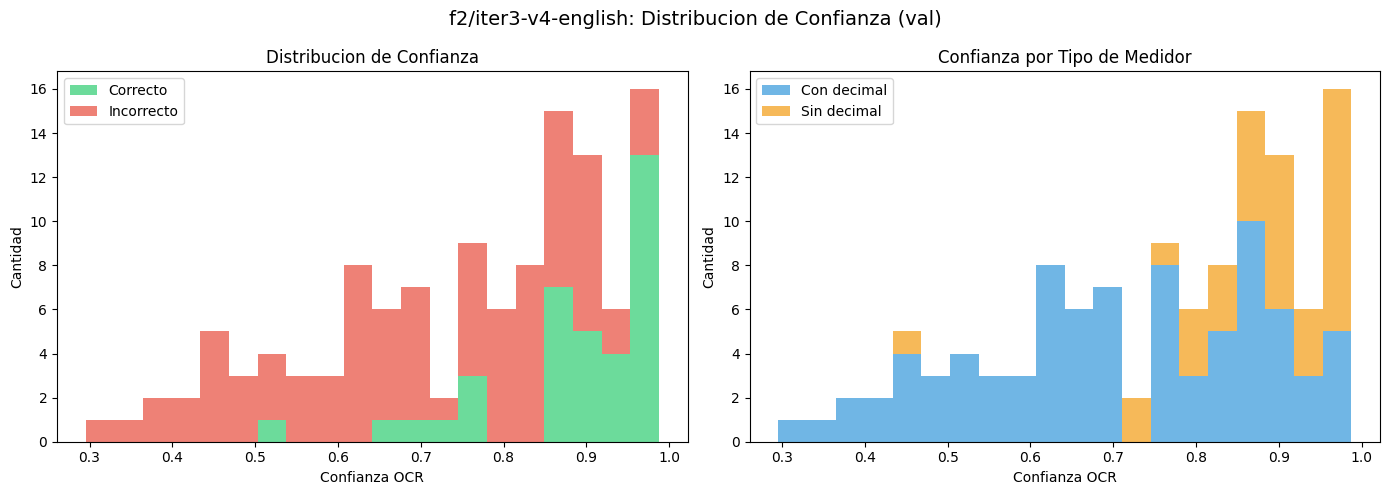

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confianza por correctitud
correct_conf = eval_df[eval_df['is_correct']]['confidence']
incorrect_conf = eval_df[~eval_df['is_correct']]['confidence']

axes[0].hist(
    [correct_conf, incorrect_conf], bins=20,
    label=['Correcto', 'Incorrecto'],
    color=['#2ecc71', '#e74c3c'], alpha=0.7, stacked=True)
axes[0].set_xlabel('Confianza OCR')
axes[0].set_ylabel('Cantidad')
axes[0].set_title('Distribucion de Confianza')
axes[0].legend()

# Confianza por tipo de medidor
dec_conf = eval_df[eval_df['has_decimal']]['confidence']
nodec_conf = eval_df[~eval_df['has_decimal']]['confidence']

axes[1].hist(
    [dec_conf, nodec_conf], bins=20,
    label=['Con decimal', 'Sin decimal'],
    color=['#3498db', '#f39c12'], alpha=0.7, stacked=True)
axes[1].set_xlabel('Confianza OCR')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Confianza por Tipo de Medidor')
axes[1].legend()

plt.suptitle(f'{RUN_NAME}: Distribucion de Confianza ({EVAL_SPLIT})', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Análisis de Errores

Categorización de errores:
- **wrong_digits**: misma longitud, dígitos diferentes
- **extra_digits**: predicción más larga que GT (posibles separadores leídos como dígitos)
- **missing_digits**: predicción más corta que GT
- **no_prediction**: OCR no detectó texto (salida vacía o sin dígitos)

In [17]:
errors_df = eval_df[~eval_df['is_correct']].copy()


def categorize_error(row):
    pred = row['prediction']
    gt = row['label']
    if pred is None:
        return 'no_prediction'
    if len(pred) > len(gt):
        return 'extra_digits'
    if len(pred) < len(gt):
        return 'missing_digits'
    return 'wrong_digits'


errors_df['error_type'] = errors_df.apply(categorize_error, axis=1)

# Resumen
error_counts = errors_df['error_type'].value_counts()
print(f"=== ANALISIS DE ERRORES ({len(errors_df)} errores en {len(eval_df)} imagenes) ===\n")
for error_type, count in error_counts.items():
    pct = count / len(eval_df) * 100
    print(f"  {error_type:20s}: {count:3d}  ({pct:.1f}%)")

# Tabla detallada
print(f"\n{'=' * 90}")
print(f"{'Archivo':12s} {'GT':>10s} {'Prediccion':>12s} {'Raw OCR':>15s} "
      f"{'Conf':>6s} {'Tipo':>15s} {'Decimal':>8s}")
print('-' * 90)
for _, row in errors_df.head(30).iterrows():
    pred_str = row['prediction'] if row['prediction'] is not None else '(None)'
    raw_str = row['raw_text'][:15] if row['raw_text'] else ''
    print(f"{row['filename']:12s} {row['label']:>10s} {pred_str:>12s} "
          f"{raw_str:>15s} {row['confidence']:>6.3f} "
          f"{row['error_type']:>15s} {str(row['has_decimal']):>8s}")

=== ANALISIS DE ERRORES (84 errores en 120 imagenes) ===

  extra_digits        :  50  (41.7%)
  missing_digits      :  22  (18.3%)
  wrong_digits        :   8  (6.7%)
  no_prediction       :   4  (3.3%)

Archivo              GT   Prediccion         Raw OCR   Conf            Tipo  Decimal
------------------------------------------------------------------------------------------
00007.jpg          3840          130            130N  0.483  missing_digits     True
00021.jpg          0000          000            p000  0.399  missing_digits     True
00038.jpg         00160         0060            0060  0.632  missing_digits     True
00046.jpg          5685           56         F56PEEH  0.462  missing_digits     True
00050.jpg          5268       153216         153216M  0.680    extra_digits     True
00064.jpg         10774    130173734       130173734  0.835    extra_digits    False
00066.jpg         13144   1133313434      1133313434  0.851    extra_digits    False
00072.jpg         14922 

### 5.4 Distribución de Longitud de Lecturas

Compara la longitud de las predicciones vs ground truth. Útil para entender el comportamiento del modelo en lecturas de diferente longitud.

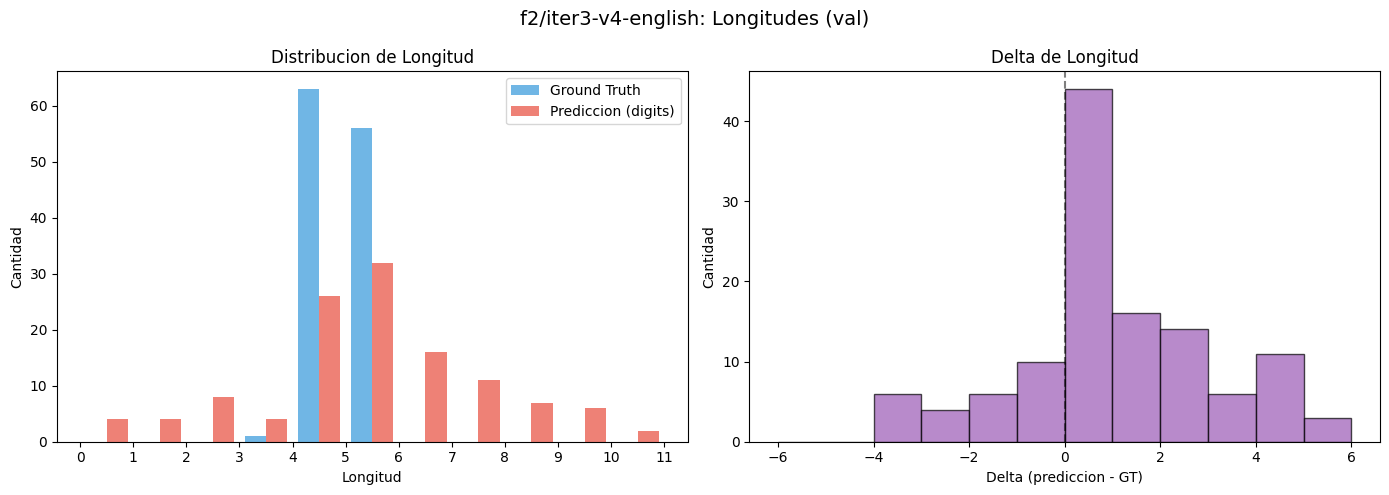

  GT lengths:   min=3, max=5, mean=4.5
  Pred lengths: min=0, max=10, mean=5.0


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gt_lengths = eval_df['label'].str.len()
pred_lengths = eval_df['digits_text'].str.len()

axes[0].hist(
    [gt_lengths, pred_lengths], bins=range(0, 12),
    label=['Ground Truth', 'Prediccion (digits)'],
    color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Cantidad')
axes[0].set_title('Distribucion de Longitud')
axes[0].legend()
axes[0].set_xticks(range(0, 12))

# Delta de longitud
length_delta = pred_lengths - gt_lengths
axes[1].hist(
    length_delta, bins=range(-6, 7),
    color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Delta (prediccion - GT)')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Delta de Longitud')
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5)

plt.suptitle(f'{RUN_NAME}: Longitudes ({EVAL_SPLIT})', fontsize=14)
plt.tight_layout()
plt.show()

print(f"  GT lengths:   min={gt_lengths.min()}, max={gt_lengths.max()}, "
      f"mean={gt_lengths.mean():.1f}")
print(f"  Pred lengths: min={pred_lengths.min()}, max={pred_lengths.max()}, "
      f"mean={pred_lengths.mean():.1f}")

### 5.5 Predicciones Incorrectas (sample visual)

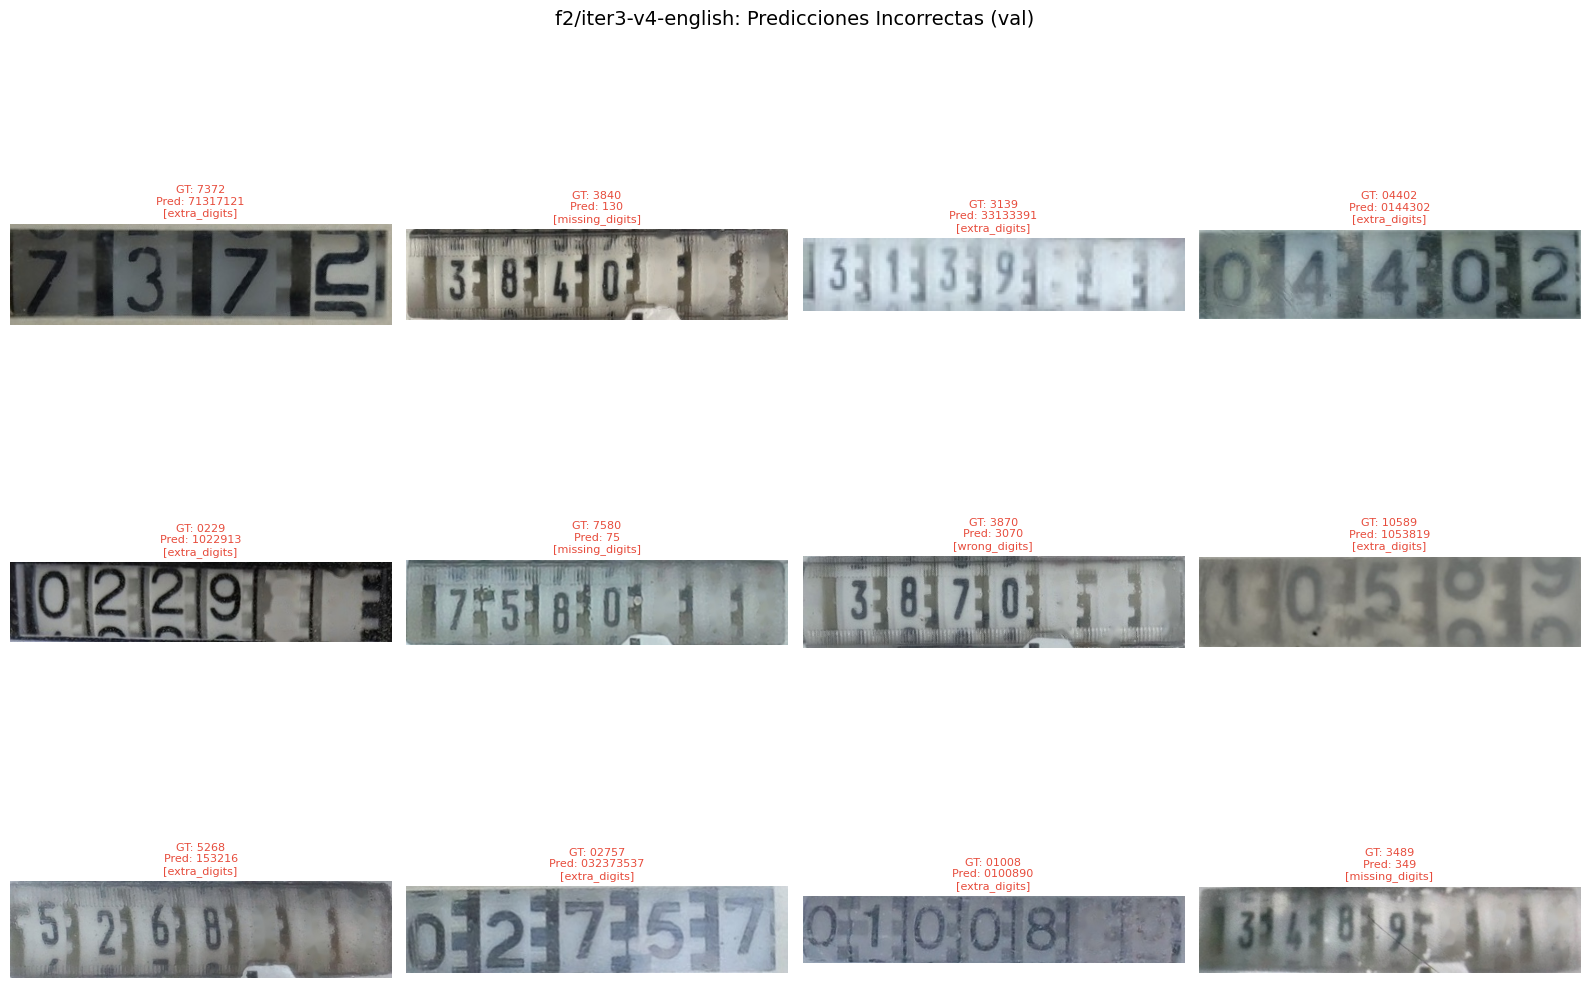

In [19]:
n_show = min(12, len(errors_df))
if n_show > 0:
    sample_errors = (
        errors_df.sample(n=n_show, random_state=42)
        if len(errors_df) > n_show else errors_df
    )

    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.ravel() if n_show > cols else (
        axes if n_show > 1 else [axes])

    for idx, (_, row) in enumerate(sample_errors.iterrows()):
        img_path = f"{DATASET_PATH}/{row['rel_path']}"
        img = Image.open(img_path)

        pred_str = row['prediction'] if row['prediction'] else '(None)'
        title = f"GT: {row['label']}\nPred: {pred_str}\n[{row['error_type']}]"

        axes[idx].imshow(img)
        axes[idx].set_title(title, fontsize=8, color='#e74c3c')
        axes[idx].axis('off')

    for idx in range(n_show, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(
        f'{RUN_NAME}: Predicciones Incorrectas ({EVAL_SPLIT})', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No hay errores para mostrar")

### 5.6 Análisis de Sustituciones por Carácter

Identifica qué dígitos se confunden más frecuentemente y en qué posiciones ocurren los errores.

In [20]:
substitution_pairs = Counter()
position_errors = Counter()

for _, row in errors_df.iterrows():
    pred = row['prediction']
    gt = row['label']
    if pred is None:
        continue

    # Alinear a nivel de caracter (comparar hasta longitud minima)
    min_len = min(len(pred), len(gt))
    for i in range(min_len):
        if pred[i] != gt[i]:
            substitution_pairs[(gt[i], pred[i])] += 1
            position_errors[i] += 1

if substitution_pairs:
    print("=== SUSTITUCIONES MAS COMUNES ===\n")
    for (gt_c, pred_c), count in substitution_pairs.most_common(15):
        print(f"  '{gt_c}' -> '{pred_c}' : {count} veces")
else:
    print("No hay sustituciones para analizar")

if position_errors:
    print(f"\n=== ERRORES POR POSICION ===\n")
    for pos, count in sorted(position_errors.items()):
        print(f"  Posicion {pos}: {count} errores")
else:
    print("No hay errores posicionales para analizar")

=== SUSTITUCIONES MAS COMUNES ===

  '3' -> '1' : 9 veces
  '7' -> '1' : 9 veces
  '8' -> '1' : 7 veces
  '2' -> '1' : 7 veces
  '1' -> '3' : 6 veces
  '4' -> '1' : 6 veces
  '0' -> '6' : 5 veces
  '6' -> '1' : 5 veces
  '7' -> '3' : 5 veces
  '0' -> '3' : 4 veces
  '8' -> '0' : 4 veces
  '2' -> '3' : 4 veces
  '6' -> '0' : 3 veces
  '6' -> '3' : 3 veces
  '4' -> '7' : 3 veces

=== ERRORES POR POSICION ===

  Posicion 0: 23 errores
  Posicion 1: 41 errores
  Posicion 2: 44 errores
  Posicion 3: 42 errores
  Posicion 4: 15 errores


### 5.7 Detecciones Multi-Línea

Analiza si los crops con múltiples líneas de texto detectadas tienen mayor tasa de error.

In [21]:
no_line = eval_df[eval_df['num_lines'] == 0]
single_line = eval_df[eval_df['num_lines'] == 1]
multi_line = eval_df[eval_df['num_lines'] > 1]

print("=== DETECCIONES POR NUMERO DE LINEAS ===")
print(f"  Sin deteccion (0): {len(no_line)} imagenes")
if len(single_line) > 0:
    print(f"  Una linea (1):     {len(single_line)} imagenes "
          f"(EM={single_line['is_correct'].mean():.4f})")
if len(multi_line) > 0:
    print(f"  Multi-linea (>1):  {len(multi_line)} imagenes "
          f"(EM={multi_line['is_correct'].mean():.4f})")

    # Distribucion de numero de lineas
    print("\n  Distribucion multi-linea:")
    for n_lines, count in sorted(
        multi_line['num_lines'].value_counts().items()):
        subset = multi_line[multi_line['num_lines'] == n_lines]
        print(f"    {n_lines} lineas: {count} imagenes "
              f"(EM={subset['is_correct'].mean():.4f})")

=== DETECCIONES POR NUMERO DE LINEAS ===
  Sin deteccion (0): 0 imagenes
  Una linea (1):     120 imagenes (EM=0.3000)


### 5.8 Resumen de Rendimiento

* **Exact Match (EM) Accuracy:** Porcentaje de predicciones donde el texto reconocido por el OCR coincide exactamente con el texto esperado (ground truth). Es la métrica principal para determinar si una lectura de odómetro es completamente correcta.

* **CER (Character Error Rate):** Mide el número de sustituciones, inserciones y eliminaciones necesarias para transformar la cadena predicha en la cadena de verdad fundamental, normalizado por la longitud de la cadena de verdad fundamental. Un CER más bajo indica mejor rendimiento a nivel de carácter.

* **CRR (Character Recognition Rate):** Complemento del CER, calculado como 1 - CER. Representa el porcentaje de caracteres que fueron reconocidos correctamente. Un CRR más alto indica mejor rendimiento a nivel de carácter.

In [22]:
m_global = metrics['global']
m_dec = metrics.get('with_decimal', {})
m_nodec = metrics.get('without_decimal', {})

print("\n" + "=" * 60)
print(f"    RESUMEN: {RUN_NAME}")
print(f"    {RUN_DESCRIPTION}")
print("=" * 60)
print(f"\n| {'Metrica':<35} | {'Valor':>10} |")
print("-" * 52)
print(f"| {'Exact Match Accuracy (global) *':<35} | {m_global['exact_match']:>10.4f} |")
print(f"| {'CER (global)':<35} | {m_global['cer']:>10.4f} |")
print(f"| {'CRR (global)':<35} | {m_global['crr']:>10.4f} |")
print("-" * 52)
if m_dec:
    print(f"| {'EM Accuracy (con decimales)':<35} | {m_dec['exact_match']:>10.4f} |")
    print(f"| {'CER (con decimales)':<35} | {m_dec['cer']:>10.4f} |")
if m_nodec:
    print(f"| {'EM Accuracy (sin decimales)':<35} | {m_nodec['exact_match']:>10.4f} |")
    print(f"| {'CER (sin decimales)':<35} | {m_nodec['cer']:>10.4f} |")
print("-" * 52)
print(f"| {'Modelo OCR':<35} | {OCR_VERSION:>10} |")
print(f"| {'Sanitization':<35} | {str(USE_SANITIZATION):>10} |")
print(f"| {'Split evaluado':<35} | {EVAL_SPLIT:>10} |")
print(f"| {'Imagenes evaluadas':<35} | {len(eval_df):>10} |")
print(f"| {'Tiempo promedio (ms)':<35} | {eval_df['time_ms'].mean():>10.0f} |")
print("=" * 60)
print("* metrica principal")


    RESUMEN: f2/iter3-v4-english
    Fase 2 — Iter 3: Rec-only PP-OCRv4 mobile english, datos P2 (LAB mask), con sanitizacion

| Metrica                             |      Valor |
----------------------------------------------------
| Exact Match Accuracy (global) *     |     0.3000 |
| CER (global)                        |     0.3907 |
| CRR (global)                        |     0.6093 |
----------------------------------------------------
| EM Accuracy (con decimales)         |     0.2857 |
| CER (con decimales)                 |     0.4100 |
| EM Accuracy (sin decimales)         |     0.3333 |
| CER (sin decimales)                 |     0.3506 |
----------------------------------------------------
| Modelo OCR                          |   PP-OCRv4 |
| Sanitization                        |       True |
| Split evaluado                      |        val |
| Imagenes evaluadas                  |        120 |
| Tiempo promedio (ms)                |         18 |
* metrica principal


---

## PARTE 6: EXPORTAR RESULTADOS

### 6.1 Exportar Artefactos de la Iteración

Genera `export/{RUN_NAME}/` con los artefactos de esta iteración. **No borra iteraciones anteriores.**

```
export/
├── baseline/
│   ├── results.csv              ← predicciones por imagen
│   ├── summary.md               ← resumen legible
│   └── eval_config.yaml         ← configuracion + metricas
├── iter1-sanitization/
└── iter2-architecture/
```

In [23]:
run_export_dir = f'{EXPORT_DIR}/{RUN_NAME}'
if os.path.exists(run_export_dir):
    shutil.rmtree(run_export_dir)
os.makedirs(run_export_dir, exist_ok=True)

# 1. Exportar CSV de resultados por imagen
results_csv_path = f'{run_export_dir}/results.csv'
export_cols = [
    'filename', 'label', 'prediction', 'raw_text', 'digits_text',
    'confidence', 'num_lines', 'time_ms', 'is_correct', 'has_decimal',
]
eval_df[export_cols].to_csv(results_csv_path, index=False)
print(f"Exportado: results.csv ({len(eval_df)} filas)")

# 2. Exportar eval_config.yaml
eval_config = {
    'run': {
        'name': RUN_NAME,
        'description': RUN_DESCRIPTION,
    },
    'model': {
        'ocr_version': OCR_VERSION,
        'ocr_det_model_name': OCR_DET_MODEL_NAME or 'DISABLED (rec-only)',
        'ocr_rec_model_name': OCR_MODEL_NAME,
        'sanitization': USE_SANITIZATION,
    },
    'evaluation': {
        'split': EVAL_SPLIT,
        'total_images': int(len(eval_df)),
        'avg_time_ms': round(float(eval_df['time_ms'].mean()), 1),
    },
    'metrics': {},
    'metadata': {
        'exported_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    },
}

for group in ['global', 'with_decimal', 'without_decimal']:
    if group in metrics:
        eval_config['metrics'][group] = {
            k: round(float(v), 4) if isinstance(v, float) else v
            for k, v in metrics[group].items()
        }

with open(f'{run_export_dir}/eval_config.yaml', 'w') as f:
    yaml.dump(eval_config, f, default_flow_style=False, sort_keys=False)
print("Exportado: eval_config.yaml")

# 3. Exportar summary.md
summary_lines = [
    f'# {RUN_NAME} \u2014 Lector OCR',
    f'> {RUN_DESCRIPTION}',
    '',
    f'- **Fecha**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **Detector**: {OCR_DET_MODEL_NAME or "DESHABILITADO (rec-only)"}',
    f'- **Reconocedor**: {OCR_MODEL_NAME}',
    f'- **Sanitization**: {USE_SANITIZATION}',
    f'- **Split**: {EVAL_SPLIT} ({len(eval_df)} imagenes)',
    f'- **Tiempo promedio**: {eval_df["time_ms"].mean():.0f} ms/imagen',
    '',
    '## Metricas',
    '',
    f'- **Exact Match Accuracy: {metrics["global"]["exact_match"]:.4f}** (principal)',
    f'- CER: {metrics["global"]["cer"]:.4f}',
    f'- CRR: {metrics["global"]["crr"]:.4f}',
]
for group, label in [('with_decimal', 'Con decimales'),
                     ('without_decimal', 'Sin decimales')]:
    if group in metrics:
        m = metrics[group]
        summary_lines += [
            '',
            f'### {label} (n={m["total"]})',
            f'- EM Accuracy: {m["exact_match"]:.4f}',
            f'- CER: {m["cer"]:.4f}',
        ]

with open(f'{run_export_dir}/summary.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines) + '\n')
print("Exportado: summary.md")

# Resumen de archivos exportados
print(f"\n{'=' * 50}")
print(f"EXPORT: {run_export_dir}")
print(f"{'=' * 50}")
for f_name in sorted(os.listdir(run_export_dir)):
    print(f"  {f_name}")

# Mostrar todas las iteraciones exportadas (recorre f1/, f2/)
all_exports = []
if os.path.exists(EXPORT_DIR):
    for phase in sorted(os.listdir(EXPORT_DIR)):
        phase_dir = f'{EXPORT_DIR}/{phase}'
        if os.path.isdir(phase_dir):
            for exp in sorted(os.listdir(phase_dir)):
                exp_path = f'{phase_dir}/{exp}'
                if os.path.isdir(exp_path):
                    all_exports.append(f'{phase}/{exp}')

if len(all_exports) > 1:
    print(f"\n--- Iteraciones exportadas ({len(all_exports)}) ---")
    for exp in all_exports:
        cfg_path = f'{EXPORT_DIR}/{exp}/eval_config.yaml'
        if os.path.exists(cfg_path):
            with open(cfg_path) as f:
                cfg = yaml.safe_load(f)
            em = cfg.get('metrics', {}).get('global', {}).get(
                'exact_match', '?')
            print(f"  {exp:30s} EM={em}")

Exportado: results.csv (120 filas)
Exportado: eval_config.yaml
Exportado: summary.md

EXPORT: /content/drive/MyDrive/water-meter-training/ocr-reader/export/f2/iter3-v4-english
  eval_config.yaml
  results.csv
  summary.md

--- Iteraciones exportadas (7) ---
  f1/p0-raw                      EM=0.0083
  f1/p1-mask-hsv                 EM=0.05
  f1/p2-mask-lab                 EM=0.0417
  f2/baseline                    EM=0.0417
  f2/iter1-det-bypass            EM=0.1583
  f2/iter2-scaling               EM=0.1333
  f2/iter3-v4-english            EM=0.3


---

## PARTE 7: RESUMEN Y SIGUIENTE ITERACIÓN

### Siguiente Iteración

Para la siguiente iteración, modificar las celdas de configuración (Parte 3):

| Si esta es... | `RUN_NAME` | Cambiar... | En celda... |
|---|---|---|---|
| **Baseline** | `f2/baseline` | — | — |
| **Iter 1** | `f2/iter1-det-bypass` | `USE_DET = False`, `OCR_DET_MODEL_NAME = None` | 3.1 |
| **Iter 2** | `f2/iter2-scaling` | `OCR_MODEL_NAME = 'PP-OCRv5_server_rec'` (rec-only server) | 3.1 |
| **Iter 3** | `f2/iter3-v4-english` | `OCR_MODEL_NAME = 'en_PP-OCRv4_mobile_rec'`, `OCR_VERSION = 'PP-OCRv4'` | 3.1 |
| **Iter 4** | `f2/iter4-finetune` | Fine-tune rec (ver notebook 05) | 3.1 |

**Regla**: si Exact Match Accuracy en val no mejora (Δ ≥ 0.5 pp), revertir el cambio.

**Test set**: solo se usa **una vez**, al final, con la configuración ganadora. Cambiar `EVAL_SPLIT = 'test'` y re-ejecutar Partes 4–6.


### Comparación entre Iteraciones

In [24]:
# Cargar todas las iteraciones exportadas y comparar (recorre f1/, f2/)
comparison_rows = []

if os.path.exists(EXPORT_DIR):
    for phase in sorted(os.listdir(EXPORT_DIR)):
        phase_dir = f'{EXPORT_DIR}/{phase}'
        if not os.path.isdir(phase_dir):
            continue
        for exp_name in sorted(os.listdir(phase_dir)):
            exp_dir = f'{phase_dir}/{exp_name}'
            full_name = f'{phase}/{exp_name}'
            cfg_path = f'{exp_dir}/eval_config.yaml'
            if os.path.isdir(exp_dir) and os.path.exists(cfg_path):
                with open(cfg_path) as f:
                    cfg = yaml.safe_load(f)

                m = cfg.get('metrics', {}).get('global', {})
                m_dec = cfg.get('metrics', {}).get('with_decimal', {})
                m_nodec = cfg.get('metrics', {}).get('without_decimal', {})

                comparison_rows.append({
                    'Iteracion': full_name,
                    'Modelo': cfg.get('model', {}).get('ocr_version', '?'),
                    'Sanitization': cfg.get('model', {}).get('sanitization', '?'),
                    'EM Acc (global)': m.get('exact_match', '?'),
                    'CER (global)': m.get('cer', '?'),
                    'EM Acc (dec)': m_dec.get('exact_match', '-'),
                    'EM Acc (nodec)': m_nodec.get('exact_match', '-'),
                })

if comparison_rows:
    comp_df = pd.DataFrame(comparison_rows)
    print("=== COMPARACION ENTRE ITERACIONES ===\n")
    print(comp_df.to_string(index=False))

    if len(comp_df) > 1:
        em_values = pd.to_numeric(comp_df['EM Acc (global)'], errors='coerce')
        best_idx = em_values.idxmax()
        print(f"\n  Mejor: {comp_df.loc[best_idx, 'Iteracion']} "
              f"(EM={comp_df.loc[best_idx, 'EM Acc (global)']})")
else:
    print("Solo hay una iteracion exportada. Ejecuta mas iteraciones para comparar.")

=== COMPARACION ENTRE ITERACIONES ===

          Iteracion   Modelo  Sanitization  EM Acc (global)  CER (global)  EM Acc (dec)  EM Acc (nodec)
          f1/p0-raw PP-OCRv5          True           0.0083        0.8617        0.0119          0.0000
     f1/p1-mask-hsv PP-OCRv5          True           0.0500        0.8224        0.0714          0.0000
     f1/p2-mask-lab PP-OCRv5          True           0.0417        0.8280        0.0595          0.0000
        f2/baseline PP-OCRv5          True           0.0417        0.8280        0.0595          0.0000
f2/iter1-det-bypass PP-OCRv5          True           0.1583        0.5009        0.1905          0.0833
   f2/iter2-scaling PP-OCRv5          True           0.1333        0.5327        0.1548          0.0833
f2/iter3-v4-english PP-OCRv4          True           0.3000        0.3907        0.2857          0.3333

  Mejor: f2/iter3-v4-english (EM=0.3)


---

## APÉNDICE: Comparación Raw vs Masked (Diagnóstico)

Ejecuta OCR sobre crops **sin HSV masking** (solo rotados) para validar que el enmascaramiento de dígitos rojos ayuda. Solo es significativo para el subconjunto `with_decimal`.

**Ejecutar después de completar las iteraciones principales**, con la mejor configuración de modelo.

In [25]:
# Cargar labels OCR para info de rotacion
ocr_labels_raw = {}
with open(OCR_LABELS_CSV) as f:
    for r in csv.DictReader(f):
        rot_str = r.get('rotation_applied', '0').strip() or '0'
        ocr_labels_raw[r['image']] = {
            'reading': r['reading'].strip(),
            'rotation': int(rot_str),
        }

ROTATION_CODES = {
    0: None,
    90: cv2.ROTATE_90_CLOCKWISE,
    180: cv2.ROTATE_180,
    270: cv2.ROTATE_90_COUNTERCLOCKWISE,
}


def apply_rotation(img, degrees):
    code = ROTATION_CODES.get(degrees)
    return cv2.rotate(img, code) if code is not None else img


# --- OCR en raw crops (sin HSV masking) ---
print("Ejecutando OCR en raw crops (sin HSV masking)...")
raw_predictions = []

for i, (_, row) in enumerate(val_df.iterrows()):
    fname = row['filename']
    raw_path = f'{RAW_CROPS_DIR}/{fname}'

    if not os.path.exists(raw_path):
        raw_predictions.append(None)
        continue

    # Aplicar solo rotacion (sin masking)
    img = cv2.imread(raw_path)
    rotation = ocr_labels_raw.get(fname, {}).get('rotation', 0)
    img = apply_rotation(img, rotation)

    # Guardar en archivo temporal para PaddleOCR
    tmp_path = '/tmp/ocr_raw_temp.jpg'
    cv2.imwrite(tmp_path, img)

    result = run_ocr_on_image(
        ocr_engine, tmp_path, apply_sanitization=USE_SANITIZATION,
        use_det=USE_DET)
    raw_predictions.append(result['prediction'])

    if (i + 1) % 30 == 0 or (i + 1) == len(val_df):
        print(f"  Procesadas {i + 1}/{len(val_df)} imagenes...")

val_df['raw_prediction'] = raw_predictions
val_df['raw_is_correct'] = val_df['raw_prediction'] == val_df['label']

# --- OCR en masked crops (reutilizar imagenes ya procesadas del dataset) ---
print("Ejecutando OCR en masked crops (val set)...")
masked_predictions = []
val_image_dir = SPLIT_IMAGE_DIRS["val"]

for i, (_, row) in enumerate(val_df.iterrows()):
    img_path = f"{val_image_dir}/{row['filename']}"

    if not os.path.exists(img_path):
        masked_predictions.append(None)
        continue

    result = run_ocr_on_image(
        ocr_engine, img_path, apply_sanitization=USE_SANITIZATION,
        use_det=USE_DET)
    masked_predictions.append(result['prediction'])

    if (i + 1) % 30 == 0 or (i + 1) == len(val_df):
        print(f"  Procesadas {i + 1}/{len(val_df)} imagenes...")

val_df['prediction'] = masked_predictions

print("Inferencia completada.")

Ejecutando OCR en raw crops (sin HSV masking)...
  Procesadas 30/120 imagenes...
  Procesadas 60/120 imagenes...
  Procesadas 90/120 imagenes...
  Procesadas 120/120 imagenes...
Ejecutando OCR en masked crops (val set)...
  Procesadas 30/120 imagenes...
  Procesadas 60/120 imagenes...
  Procesadas 90/120 imagenes...
  Procesadas 120/120 imagenes...
Inferencia completada.


In [26]:
# Comparar masked vs raw en subconjunto with_decimal
dec_df = val_df[val_df['has_decimal'] == True].copy()
nodec_df = val_df[val_df['has_decimal'] == False].copy()

masked_metrics_dec = compute_metrics(
    dec_df['prediction'].tolist(), dec_df['label'].tolist())
raw_metrics_dec = compute_metrics(
    dec_df['raw_prediction'].tolist(), dec_df['label'].tolist())

print("=== COMPARACION: RAW vs MASKED (solo with_decimal, val) ===\n")
print(f"| {'Metrica':<25} | {'Raw':>10} | {'Masked':>10} | {'Delta':>10} |")
print("-" * 65)
for metric_name in ['exact_match', 'cer', 'crr']:
    raw_val = raw_metrics_dec[metric_name]
    masked_val = masked_metrics_dec[metric_name]
    delta = masked_val - raw_val
    sign = '+' if delta > 0 else ''
    print(f"| {metric_name:<25} | {raw_val:>10.4f} | {masked_val:>10.4f} "
          f"| {sign}{delta:>9.4f} |")

# Sanity check en sin_decimal (deben ser similares)
if len(nodec_df) > 0:
    nodec_masked = compute_metrics(
        nodec_df['prediction'].tolist(), nodec_df['label'].tolist())
    nodec_raw = compute_metrics(
        nodec_df['raw_prediction'].tolist(), nodec_df['label'].tolist())
    print(f"\nSanity check (sin decimales): "
          f"masked EM={nodec_masked['exact_match']:.4f}, "
          f"raw EM={nodec_raw['exact_match']:.4f} "
          f"(deberian ser similares)")

=== COMPARACION: RAW vs MASKED (solo with_decimal, val) ===

| Metrica                   |        Raw |     Masked |      Delta |
-----------------------------------------------------------------
| exact_match               |     0.0000 |     0.2857 | +   0.2857 |
| cer                       |     0.9058 |     0.4100 |   -0.4958 |
| crr                       |     0.0942 |     0.5900 | +   0.4958 |

Sanity check (sin decimales): masked EM=0.3333, raw EM=0.3333 (deberian ser similares)


Masking ayudo:    24 imagenes (raw incorrecto, masked correcto)
Masking perjudico: 0 imagenes (raw correcto, masked incorrecto)
Ambos correctos:  0
Ambos incorrectos: 60


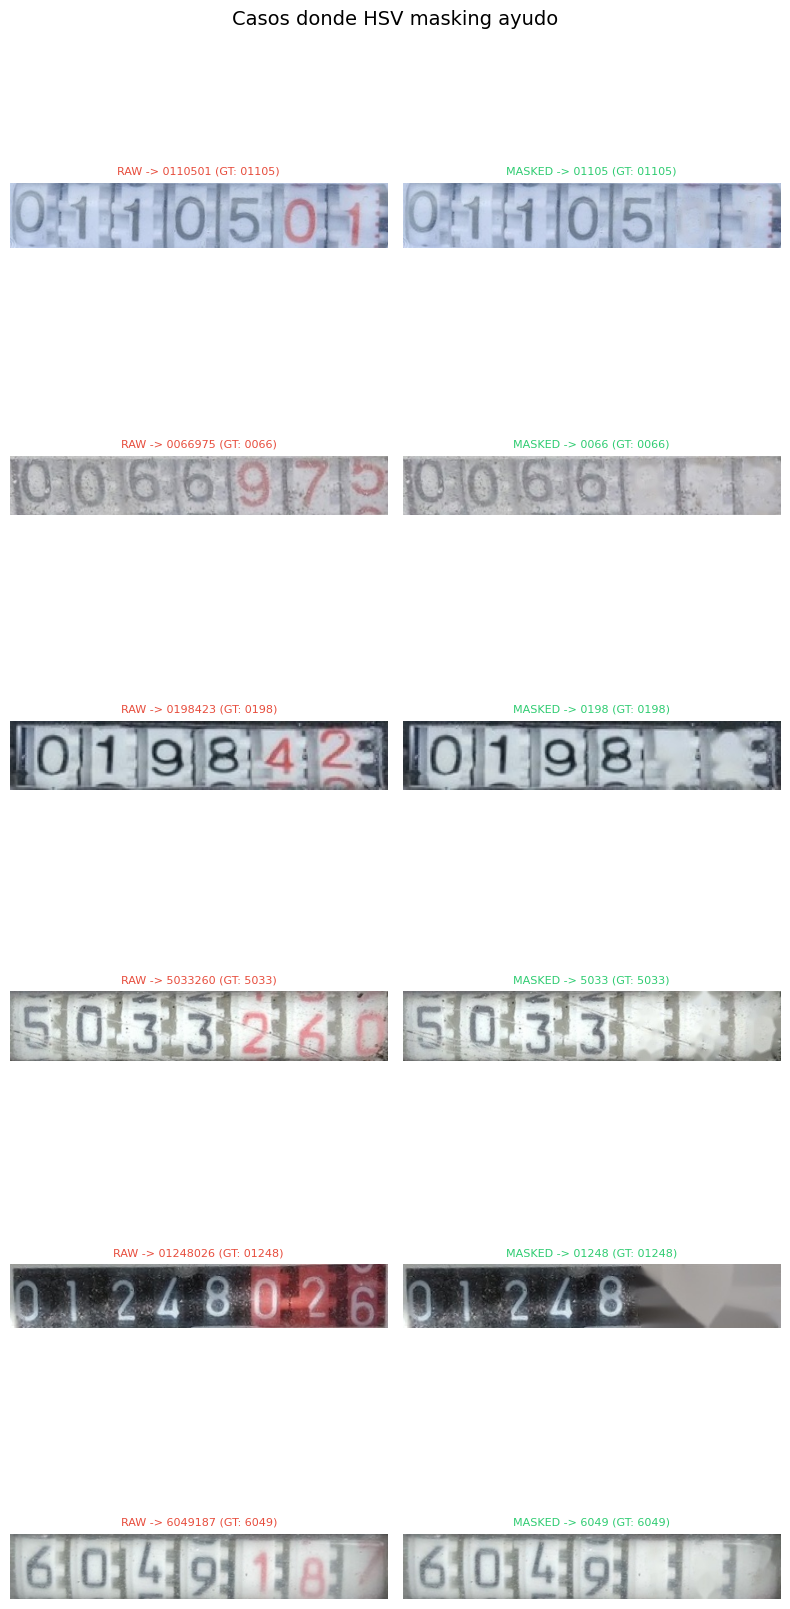

In [27]:
# Visualizar casos donde masking hizo diferencia
dec_df_viz = dec_df.copy()
dec_df_viz['masked_correct'] = dec_df_viz['prediction'] == dec_df_viz['label']
dec_df_viz['raw_correct'] = dec_df_viz['raw_prediction'] == dec_df_viz['label']

# Casos donde masked acerto y raw fallo
mask_helped = dec_df_viz[
    (dec_df_viz['masked_correct']) & (~dec_df_viz['raw_correct'])]
# Casos donde raw acerto y masked fallo
mask_hurt = dec_df_viz[
    (~dec_df_viz['masked_correct']) & (dec_df_viz['raw_correct'])]

print(f"Masking ayudo:    {len(mask_helped)} imagenes "
      f"(raw incorrecto, masked correcto)")
print(f"Masking perjudico: {len(mask_hurt)} imagenes "
      f"(raw correcto, masked incorrecto)")
print(f"Ambos correctos:  "
      f"{(dec_df_viz['masked_correct'] & dec_df_viz['raw_correct']).sum()}")
print(f"Ambos incorrectos: "
      f"{(~dec_df_viz['masked_correct'] & ~dec_df_viz['raw_correct']).sum()}")

# Mostrar hasta 6 ejemplos donde masking ayudo
n_show = min(6, len(mask_helped))
if n_show > 0:
    sample = mask_helped.head(n_show)
    fig, axes = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)

    for idx, (_, row) in enumerate(sample.iterrows()):
        # Raw crop
        raw_path = f'{RAW_CROPS_DIR}/{row["filename"]}'
        raw_img = cv2.imread(raw_path)
        rotation = ocr_labels_raw.get(row['filename'], {}).get('rotation', 0)
        raw_img = apply_rotation(raw_img, rotation)
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

        # Masked crop
        masked_path = f"{DATASET_PATH}/images/val/{row['filename']}"
        masked_img = Image.open(masked_path)

        raw_pred = row['raw_prediction'] or '(None)'
        masked_pred = row['prediction'] or '(None)'

        axes[idx, 0].imshow(raw_img)
        axes[idx, 0].set_title(
            f"RAW -> {raw_pred} (GT: {row['label']})",
            fontsize=8, color='#e74c3c')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(masked_img)
        axes[idx, 1].set_title(
            f"MASKED -> {masked_pred} (GT: {row['label']})",
            fontsize=8, color='#2ecc71')
        axes[idx, 1].axis('off')

    plt.suptitle('Casos donde HSV masking ayudo', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No hay casos donde masking hizo diferencia")